# 06 — Build the frozen XAI image set (30 images, 6 per class)

Selects a fixed, stratified sample of 30 test-set images — six from each of the five DR grades — drawn only from the **deduplicated test split**, and saves them as a shared artifact. Every XAI notebook (07a–07e) loads this exact set, so heatmaps are computed on identical images and the cross-method IoU comparison is fair.

Saves to `/kaggle/working/`:
- `xai_indices.npy` — the 30 dataset indices (into the full ImageFolder)
- `xai_images.npy` — the 30 preprocessed 224×224 image tensors (ImageNet-normalised)
- `xai_labels.npy` — their true class labels
- `xai_manifest.csv` — human-readable list (index, class, file path)

**Setup:** attach the dataset and build_clean_split. Run All. Then commit so 07a–07e can attach it.

In [1]:
DATA_ROOT = "/kaggle/input/datasets/shajinrp/diabetic-retinopathy/Dataset"
SPLIT_DIR = "/kaggle/input/notebooks/tochyokafor/build-clean-split"
OUT = "/kaggle/working"
PER_CLASS = 6      # 6 x 5 classes = 30 images
SEED = 42

import os, numpy as np, torch, pandas as pd
from torchvision import datasets, transforms
for p in [DATA_ROOT, SPLIT_DIR]: assert os.path.isdir(p), p
print("Paths OK")

Paths OK


In [2]:
# Standard ImageNet preprocessing at 224x224 (matches all 224px models).
# Inception (299px) is handled inside its own XAI notebook by re-resizing;
# the frozen set is stored at 224 and upsampled where needed.
NORM = transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
tf = transforms.Compose([transforms.Resize((224,224)), transforms.ToTensor(), NORM])

full = datasets.ImageFolder(DATA_ROOT, transform=tf)
class_names = full.classes
labels = np.array([lbl for _,lbl in full.samples])
test_idx = np.load(f"{SPLIT_DIR}/clean_test_indices.npy")
print("Classes:", class_names)
print("Test-set size:", len(test_idx))

Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Test-set size: 536


In [3]:
# Stratified sample: PER_CLASS images from each class, drawn ONLY from the test split.
rng = np.random.default_rng(SEED)
chosen = []
for c in range(len(class_names)):
    pool = [i for i in test_idx if labels[i]==c]
    if len(pool) < PER_CLASS:
        print(f"WARNING: class {class_names[c]} has only {len(pool)} test images")
    pick = rng.choice(pool, size=min(PER_CLASS,len(pool)), replace=False)
    chosen.extend(sorted(pick.tolist()))
chosen = np.array(chosen)
print(f"Selected {len(chosen)} images ({PER_CLASS} per class)")
for c in range(len(class_names)):
    print(f"  {class_names[c]:<16}: {(labels[chosen]==c).sum()}")

Selected 30 images (6 per class)
  Mild            : 6
  Moderate        : 6
  No_DR           : 6
  Proliferate_DR  : 6
  Severe          : 6


In [4]:
# Materialise the preprocessed tensors and save everything
imgs = torch.stack([full[i][0] for i in chosen])   # (30, 3, 224, 224)
lbls = labels[chosen]
paths = [full.samples[i][0] for i in chosen]

np.save(f"{OUT}/xai_indices.npy", chosen)
np.save(f"{OUT}/xai_images.npy", imgs.numpy())
np.save(f"{OUT}/xai_labels.npy", lbls)
pd.DataFrame({"dataset_index":chosen,"class":[class_names[l] for l in lbls],
              "path":paths}).to_csv(f"{OUT}/xai_manifest.csv", index=False)
with open(f"{OUT}/xai_class_names.txt","w") as f: f.write("\n".join(class_names))
print("Saved: xai_indices.npy, xai_images.npy, xai_labels.npy, xai_manifest.csv, xai_class_names.txt")

Saved: xai_indices.npy, xai_images.npy, xai_labels.npy, xai_manifest.csv, xai_class_names.txt


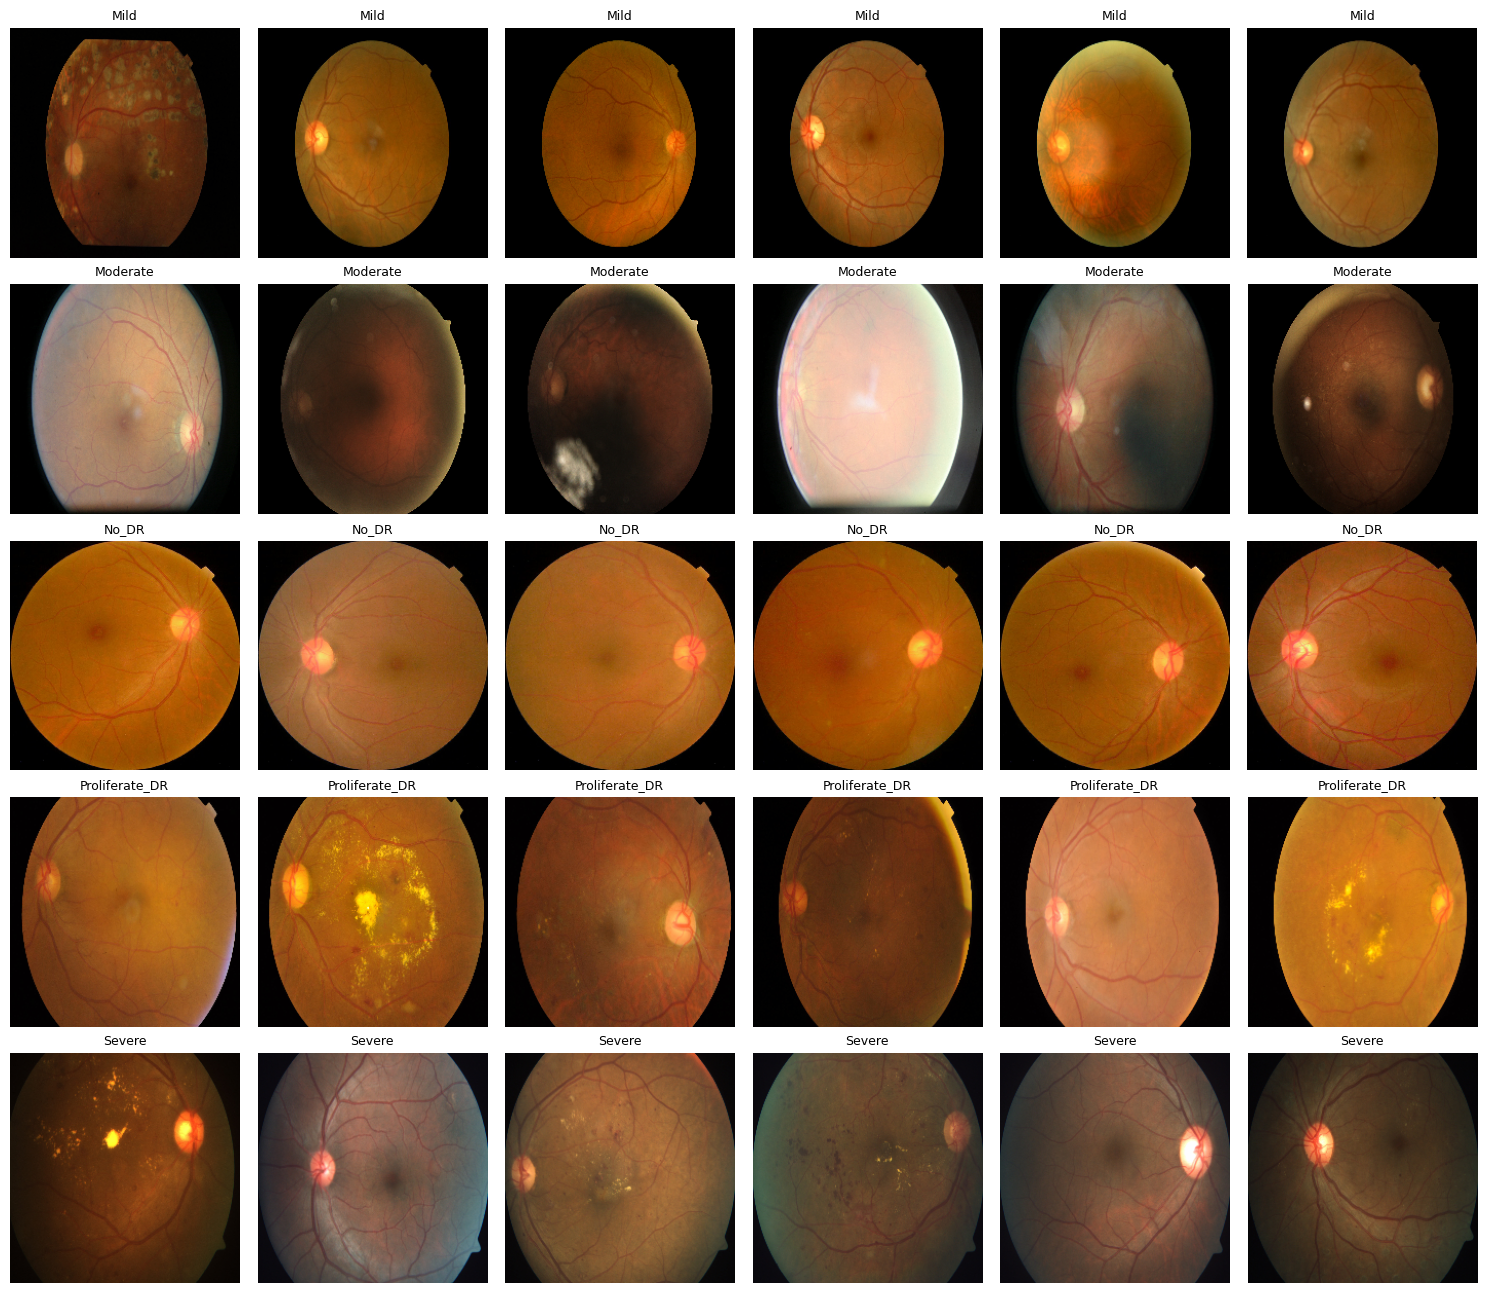

Frozen XAI set ready. Commit this notebook, then attach its output to 07a-07e.


In [5]:
# Preview the 30 selected images
import matplotlib.pyplot as plt
def denorm(t):
    m=np.array([0.485,0.456,0.406]); s=np.array([0.229,0.224,0.225])
    a=t.permute(1,2,0).numpy()*s+m; return np.clip(a,0,1)
fig,axes=plt.subplots(5,6,figsize=(15,13))
for k,idx in enumerate(range(len(chosen))):
    ax=axes[k//6][k%6]; ax.imshow(denorm(imgs[idx])); ax.axis("off")
    ax.set_title(class_names[lbls[idx]], fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/xai_image_set_preview.png",dpi=120,bbox_inches="tight")
plt.show()
print("Frozen XAI set ready. Commit this notebook, then attach its output to 07a-07e.")